In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import logging
import tensorflow as tf
import tensorflow_datasets as tfds
from urllib import parse
from http.server import HTTPServer, BaseHTTPRequestHandler
import yfinance as yf


In [2]:
msft = yf.Ticker("MSFT")
for key, value in msft.info.items():
    print(f"{key}: {value}")


address1: One Microsoft Way
city: Redmond
state: WA
zip: 98052-6399
country: United States
phone: 425 882 8080
website: https://www.microsoft.com
industry: Software - Infrastructure
industryKey: software-infrastructure
industryDisp: Software - Infrastructure
sector: Technology
sectorKey: technology
sectorDisp: Technology
longBusinessSummary: Microsoft Corporation develops and supports software, services, devices, and solutions worldwide. The Productivity and Business Processes segment offers Microsoft 365 commercial, enterprise mobility + security, windows commercial, power BI, exchange, sharepoint, Microsoft teams, security and compliance, and copilot; Microsoft 365 commercial products, such as Windows commercial on-premises and office licensed services; Microsoft 365 consumer products and cloud services, including Microsoft 365 consumer subscriptions, office licensed on-premises, and other consumer services; LinkedIn; dynamics products and cloud services, such as dynamics 365, cloud-

In [3]:
def get_prices(share_symbol, start_date, end_date, cache_filename):
    try:
        stock_prices = np.load(cache_filename)
    except IOError:
        ticker = yf.Ticker(share_symbol)
        stock_hist = ticker.history(start=start_date, end=end_date)
        stock_prices = stock_hist['Open'].values
        np.save(cache_filename, stock_prices)
    return stock_prices

In [4]:
def plot_prices(prices):
    plt.title("open stock prices")
    plt.xlabel("day")
    plt.ylabel("price ($)")
    plt.plot(prices)
    plt.savefig('prices.png')

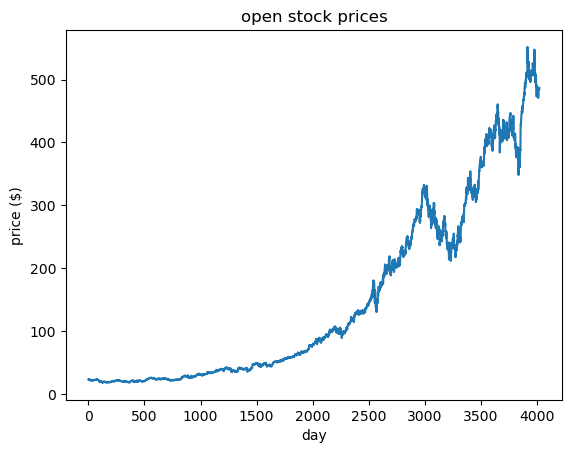

In [5]:
prices = get_prices("MSFT", '2010-01-01', '2026-01-01', 'historical_stock_prices.npy')
plot_prices(prices)